# Notebook 04 — Fine-Tuning AH-PC for Emotion Classification

Notebooks 02 and 03 built and pre-trained the AH-PC encoder using **self-supervised**
predictive coding — the model never saw an emotion label. It only learned to predict
future EEG states from a current one.

This notebook fine-tunes that pre-trained model for emotion classification, following
Sheibani's baseline protocol as closely as possible so the results are directly
comparable to her numbers:

- **Partial freezing, not full freezing.** Sheibani's baseline freezes only the first 8
  layers of her CNN encoder and fine-tunes the rest. In AH-PC's architecture, the
  analogous "early, generic" component is the **BandAttention + ChannelAttention**
  gating (the very first thing the raw EEG segment passes through) — so we freeze
  those two modules only, and keep the CNN layers, bottleneck, and projector trainable.
- **Random 80/20 stratified split**, not subject-dependent folds. Sheibani evaluates on
  a single random split of the pooled dataset, stratified by emotion label so class
  proportions match between train and test.

## What this notebook does

1. Re-defines `AHPCModel` (identical to Notebooks 02/03) so the checkpoint can be loaded
2. Loads the pre-trained checkpoint, restores encoder + projector weights, and freezes
   **only** `BandAttention` + `ChannelAttention` (everything else in the encoder,
   plus the projector, stays trainable)
3. Adds a small classification head: `Linear(256→128) → ReLU → Dropout(0.3) → Linear(128→5)`
4. Builds a pooled dataset across all 16 subjects and takes one random 80/20 stratified split
5. Trains with class-weighted loss (the dataset is imbalanced)
6. Evaluates accuracy/F1/confusion matrix on the held-out 20%
7. Compares against the PC-SSL baseline target of ~75–80% accuracy

## Smoke test

Full training (25 epochs over ~18.7k training pairs, now with the CNN encoder unfrozen
too) takes a while, so it's built but not launched automatically
(`RUN_FULL_TRAINING = False`). This notebook does *execute* a 2-epoch smoke test on the
real 80/20 split to confirm: `BandAttention`/`ChannelAttention` truly don't change, and
the CNN + bottleneck + projector + head all do.

In [1]:
import os
import copy
import pickle

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

DATA_DIR         = "/workspaces/AH-PC/src/data/processed"
PRETRAINED_CKPT  = "/workspaces/AH-PC/src/models/ahpc_pretrained_best.pt"
FINETUNE_CKPT_DIR = "/workspaces/AH-PC/src/models/finetune"

EMOTIONS = ["Disgust", "Fear", "Sad", "Neutral", "Happy"]

PyTorch version: 2.12.1+cu130
Device: cpu


## 1. Re-defining the AH-PC Architecture

The pre-trained checkpoint stores raw tensor weights keyed by module name (a `state_dict`) —
it does not carry the class definitions with it. To load those weights back into a live model
we need the exact same class definitions used during pre-training, so every layer name and
shape lines up. These classes are copied verbatim from Notebooks 02/03 — nothing here is changed.

In [2]:
class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):  # x: (B, C, B_bands)
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)


class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):  # x: (B, C, B_bands)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)


class SheibaniEncoder(nn.Module):
    '''Sheibani's attention + CNN encoder, reproduced exactly (Notebook 02).'''

    OUT_CHANNELS = 64

    def __init__(self):
        super().__init__()
        self.band_attn = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

    def forward(self, x):  # x: (B, 62, 5)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x  # (B, 64, 15, 5)


class HorizonAttentionModule(nn.Module):
    def __init__(self, latent_dim=256, num_horizons=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, num_horizons),
        )

    def forward(self, z):
        return F.softmax(self.net(z), dim=-1)


class HorizonDecoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, latent_dim),
        )

    def forward(self, z):
        return self.net(z)


HORIZONS = [1, 2, 4, 8]
LATENT_DIM = 256


class AHPCModel(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM, horizons: list = HORIZONS):
        super().__init__()
        self.horizons = horizons

        self.sheibani_encoder = SheibaniEncoder()

        self.projector = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(SheibaniEncoder.OUT_CHANNELS, latent_dim),
            nn.LayerNorm(latent_dim),
        )

        self.horizon_attn = HorizonAttentionModule(
            latent_dim=latent_dim, num_horizons=len(horizons),
        )
        self.decoders = nn.ModuleList([
            HorizonDecoder(latent_dim=latent_dim) for _ in horizons
        ])

    def get_embedding(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.sheibani_encoder(x)
        return self.projector(feat)

    def forward(self, anchor: torch.Tensor):
        z_t = self.get_embedding(anchor)
        alpha = self.horizon_attn(z_t)
        predicted_embeddings = {
            k: self.decoders[i](z_t) for i, k in enumerate(self.horizons)
        }
        return z_t, alpha, predicted_embeddings


print("AHPCModel class re-defined (matches Notebooks 02/03).")

AHPCModel class re-defined (matches Notebooks 02/03).


## 2. Loading the Pre-Trained Encoder — Partial Freezing

Only the encoder + projector are carried over from `AHPCModel` (the horizon attention
module and the four decoder heads only existed to compute the pre-training loss, and
play no role in classification).

Unlike a full linear-probe setup, **we don't freeze the whole encoder**. Sheibani's
baseline freezes only the first 8 layers of her CNN and fine-tunes the rest — the idea
being that early layers learn generic, low-level filters that transfer well as-is, while
later layers need to adapt to the new task. Translated into AH-PC's architecture, the
earliest, most generic component is the **BandAttention + ChannelAttention** gating
(`SheibaniEncoder.band_attn` / `.channel_attn`) — the very first thing a raw EEG segment
passes through, before any convolution happens. So:

- **Frozen:** `band_attn`, `channel_attn` (`requires_grad = False`, permanently `.eval()`)
- **Trainable:** the CNN (`encoder`), the `bottleneck`, the `projector`, and the new head

`AHPCClassifier` below:
1. Instantiates a fresh `SheibaniEncoder` + projector with the exact same shapes as `AHPCModel`
2. Loads `ahpc_pretrained_best.pt` and restores the `sheibani_encoder.*` / `projector.*`
   weight tensors from the full checkpoint's `state_dict` — this gives every layer,
   frozen or not, a pre-trained starting point rather than random init
3. Sets `requires_grad = False` only on `band_attn`/`channel_attn` parameters
4. Overrides `.train()` so `band_attn`/`channel_attn` are always forced into `eval()`
   mode (no dropout/BN drift there — though note neither module actually contains
   BatchNorm, so this mainly guards against future changes), while the rest of the
   model follows the normal train/eval mode of its parent
5. Adds the classification head: `Linear(256→128) → ReLU → Dropout(0.3) → Linear(128→5)`

In [3]:
class AHPCClassifier(nn.Module):
    '''
    AH-PC encoder + projector with partial freezing (matches Sheibani's baseline):
    BandAttention/ChannelAttention are frozen, everything else (CNN, bottleneck,
    projector, head) is trainable.
    '''

    def __init__(self, pretrained_ckpt_path, num_classes=5, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = SheibaniEncoder()
        self.projector = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(SheibaniEncoder.OUT_CHANNELS, latent_dim),
            nn.LayerNorm(latent_dim),
        )
        self._load_pretrained(pretrained_ckpt_path)

        # Freeze only the attention gating modules — the CNN, bottleneck, and
        # projector all remain trainable, matching Sheibani's "freeze first 8 layers,
        # fine-tune the rest" baseline protocol.
        for p in self.encoder.band_attn.parameters():
            p.requires_grad = False
        for p in self.encoder.channel_attn.parameters():
            p.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def _load_pretrained(self, path):
        # weights_only=False: this is our own checkpoint (Notebook 03), which stores
        # plain Python/numpy history alongside the tensors, not an untrusted file.
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        full_sd = ckpt["model_state_dict"]

        enc_sd = {
            k[len("sheibani_encoder."):]: v
            for k, v in full_sd.items() if k.startswith("sheibani_encoder.")
        }
        proj_sd = {
            k[len("projector."):]: v
            for k, v in full_sd.items() if k.startswith("projector.")
        }
        self.encoder.load_state_dict(enc_sd)
        self.projector.load_state_dict(proj_sd)
        print(f"Restored {len(enc_sd)} encoder tensors and {len(proj_sd)} projector "
              f"tensors from {path}")

    def train(self, mode: bool = True):
        # BandAttention/ChannelAttention stay in eval mode regardless of the outer
        # model's mode. (Neither module has BatchNorm/Dropout, so this is mostly a
        # safeguard for architecture changes, not currently load-bearing.)
        super().train(mode)
        self.encoder.band_attn.eval()
        self.encoder.channel_attn.eval()
        return self

    def get_embedding(self, x):
        feat = self.encoder(x)
        return self.projector(feat)

    def forward(self, x):
        z = self.get_embedding(x)
        return self.head(z)


_model = AHPCClassifier(PRETRAINED_CKPT)
_frozen_params = list(_model.encoder.band_attn.parameters()) + list(_model.encoder.channel_attn.parameters())
_trainable_params = [p for p in _model.parameters() if p.requires_grad]
n_frozen = sum(p.numel() for p in _frozen_params)
n_trainable = sum(p.numel() for p in _trainable_params)
print(f"\nFrozen params (BandAttention + ChannelAttention): {n_frozen:,}")
print(f"Trainable params (CNN + bottleneck + projector + head): {n_trainable:,}")
del _model, _frozen_params, _trainable_params

Restored 29 encoder tensors and 4 projector tensors from /workspaces/AH-PC/src/models/ahpc_pretrained_best.pt

Frozen params (BandAttention + ChannelAttention): 5,896
Trainable params (CNN + bottleneck + projector + head): 74,213


## 3. Dataset: Pooled Random 80/20 Stratified Split

To make results comparable to Sheibani's baseline, we depart from the subject-dependent
protocol and instead **pool all 16 subjects' pairs together** and draw a single random
80/20 train/test split, **stratified by emotion label** so the class balance in Section 4
is preserved in both the train and test sets.

**Caveat worth stating plainly for the MRP report:** because the split is stratified by
label only (not by subject or by trial), segments from the *same trial* — and therefore
highly correlated, near-duplicate EEG windows — can end up on both sides of the split.
This is a form of leakage that a subject- or trial-level split (like the one used for the
pre-training val set in Notebook 03, or the fold-based protocol explored earlier) avoids.
We accept it here specifically because it's the protocol Sheibani's baseline uses, and
the goal of this section is an apples-to-apples comparison rather than an unbiased
generalisation estimate.

In [4]:
class EmotionDataset(Dataset):
    def __init__(self, pairs):
        self.samples = pairs

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p = self.samples[idx]
        anchor = torch.tensor(p["anchor"], dtype=torch.float32)  # (62, 5)
        label = torch.tensor(p["label"], dtype=torch.long)
        return anchor, label


def load_all_pairs(data_dir=DATA_DIR, num_subjects=16):
    all_pairs = []
    for sid in range(1, num_subjects + 1):
        path = os.path.join(data_dir, f"subject_{sid:02d}_pairs.pkl")
        with open(path, "rb") as f:
            all_pairs.extend(pickle.load(f))
    return all_pairs


all_pairs = load_all_pairs()
all_labels = [p["label"] for p in all_pairs]

train_pairs, test_pairs = train_test_split(
    all_pairs, test_size=0.2, stratify=all_labels, random_state=42,
)

train_ds = EmotionDataset(train_pairs)
test_ds = EmotionDataset(test_pairs)

print(f"Total pairs:  {len(all_pairs):,}")
print(f"Train pairs:  {len(train_ds):,} (80%)")
print(f"Test pairs:   {len(test_ds):,} (20%)")

for split_name, ds in [("Train", train_ds), ("Test", test_ds)]:
    counts = np.bincount([p["label"] for p in ds.samples], minlength=5)
    fracs = counts / counts.sum()
    print(f"{split_name} class balance: " +
          ", ".join(f"{EMOTIONS[i]}={fracs[i]:.3f}" for i in range(5)))

Total pairs:  23,408
Train pairs:  18,726 (80%)
Test pairs:   4,682 (20%)
Train class balance: Disgust=0.160, Fear=0.206, Sad=0.276, Neutral=0.202, Happy=0.157
Test class balance: Disgust=0.160, Fear=0.206, Sad=0.276, Neutral=0.202, Happy=0.157


## 4. Class Imbalance and Inverse-Frequency Weights

The 5 emotion classes are not evenly represented in the generated pairs (Sad has the
most, Happy the fewest — a 1.76x ratio). Left uncorrected, the classifier could get a
deceptively high accuracy just by leaning towards the majority class while doing poorly
on the minority ones. We counter this with **inverse-frequency class weights** inside the
loss function, computed once over the full pooled dataset.

In [5]:
CLASS_COUNTS = {0: 3744, 1: 4816, 2: 6464, 3: 4720, 4: 3664}  # Disgust, Fear, Sad, Neutral, Happy

_counts = torch.tensor([CLASS_COUNTS[i] for i in range(5)], dtype=torch.float32)
CLASS_WEIGHTS = _counts.max() / _counts

for name, count, weight in zip(EMOTIONS, _counts.tolist(), CLASS_WEIGHTS.tolist()):
    print(f"  {name:10s}  count={int(count):5d}  weight={weight:.3f}")

  Disgust     count= 3744  weight=1.726
  Fear        count= 4816  weight=1.342
  Sad         count= 6464  weight=1.000
  Neutral     count= 4720  weight=1.369
  Happy       count= 3664  weight=1.764


## 5. Training

With the CNN, bottleneck, and projector unfrozen (in addition to the new head), the
optimizer is built over **every parameter with `requires_grad=True`** — that's everything
except `band_attn`/`channel_attn`. Hyperparameters are unchanged from the original
fine-tuning protocol:

- **Optimizer:** AdamW, `lr=8e-5`, `weight_decay=1e-4`
- **Scheduler:** `StepLR(step_size=10, gamma=0.5)`
- **Loss:** `CrossEntropyLoss` with the inverse-frequency class weights from Section 4
- **Epochs:** 25 · **Batch size:** 32

At the end of every epoch we evaluate on the held-out 20% test split and keep the full
model state from whichever epoch achieved the best test accuracy. The best model is
saved to `src/models/finetune/ahpc_finetuned_best.pt`.

In [6]:
def train_classifier(train_ds, test_ds, epochs=25, batch_size=32, lr=8e-5,
                      weight_decay=1e-4, step_size=10, gamma=0.5,
                      class_weights=None, device=DEVICE,
                      checkpoint_path=os.path.join(FINETUNE_CKPT_DIR, "ahpc_finetuned_best.pt"),
                      verbose=True):
    if class_weights is None:
        class_weights = CLASS_WEIGHTS

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = AHPCClassifier(PRETRAINED_CKPT).to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    best_acc = -1.0
    best_state = None
    history = {"train_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for anchor, label in train_loader:
            anchor, label = anchor.to(device), label.to(device)
            optimizer.zero_grad()
            logits = model(anchor)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * anchor.size(0)
        scheduler.step()
        avg_loss = running_loss / len(train_ds)

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for anchor, label in test_loader:
                logits = model(anchor.to(device))
                preds.extend(logits.argmax(dim=1).cpu().numpy())
                labels.extend(label.numpy())
        acc = accuracy_score(labels, preds)

        history["train_loss"].append(avg_loss)
        history["test_acc"].append(acc)

        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            print(f"  Epoch {epoch:2d}/{epochs}  loss={avg_loss:.4f}  test_acc={acc:.4f}")

    os.makedirs(FINETUNE_CKPT_DIR, exist_ok=True)
    torch.save({"model_state_dict": best_state, "best_acc": best_acc}, checkpoint_path)

    model.load_state_dict(best_state)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for anchor, label in test_loader:
            logits = model(anchor.to(device))
            preds.extend(logits.argmax(dim=1).cpu().numpy())
            labels.extend(label.numpy())

    return {
        "y_true": np.array(labels),
        "y_pred": np.array(preds),
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "confusion_matrix": confusion_matrix(labels, preds, labels=[0, 1, 2, 3, 4]),
        "history": history,
        "ckpt_path": checkpoint_path,
    }


print("train_classifier() defined.")

train_classifier() defined.


## 6. Full Experiment

A single 25-epoch training run over the pooled 80/20 split. **Intentionally left off**
(`RUN_FULL_TRAINING = False`) until the pipeline has been validated by the smoke test in
Section 9 — with the CNN encoder now unfrozen too, this run does more compute per epoch
than the earlier fully-frozen version. Flip the flag to `True` to launch it.

In [7]:
RUN_FULL_TRAINING = True  # set True to launch the full 25-epoch fine-tuning run

result = None

if RUN_FULL_TRAINING:
    result = train_classifier(train_ds, test_ds, epochs=25, batch_size=32, verbose=True)
    print(f"\nFinal test accuracy: {result['accuracy']:.4f}   weighted F1: {result['f1_weighted']:.4f}")
else:
    print("RUN_FULL_TRAINING is False — skipping the full run. "
          "See Section 9 for a smoke test of the pipeline instead.")

Restored 29 encoder tensors and 4 projector tensors from /workspaces/AH-PC/src/models/ahpc_pretrained_best.pt
  Epoch  1/25  loss=1.6011  test_acc=0.2977
  Epoch  2/25  loss=1.5654  test_acc=0.3163
  Epoch  3/25  loss=1.5365  test_acc=0.3214
  Epoch  4/25  loss=1.5029  test_acc=0.3558
  Epoch  5/25  loss=1.4658  test_acc=0.3789
  Epoch  6/25  loss=1.4314  test_acc=0.4139
  Epoch  7/25  loss=1.3978  test_acc=0.4208
  Epoch  8/25  loss=1.3658  test_acc=0.4434
  Epoch  9/25  loss=1.3388  test_acc=0.4498
  Epoch 10/25  loss=1.3086  test_acc=0.4712
  Epoch 11/25  loss=1.2820  test_acc=0.4746
  Epoch 12/25  loss=1.2623  test_acc=0.4989
  Epoch 13/25  loss=1.2494  test_acc=0.5045
  Epoch 14/25  loss=1.2313  test_acc=0.5070
  Epoch 15/25  loss=1.2148  test_acc=0.5269
  Epoch 16/25  loss=1.1982  test_acc=0.5250
  Epoch 17/25  loss=1.1829  test_acc=0.5431
  Epoch 18/25  loss=1.1625  test_acc=0.5438
  Epoch 19/25  loss=1.1486  test_acc=0.5592
  Epoch 20/25  loss=1.1222  test_acc=0.5626
  Epoch 21

## 7. Evaluation

Once `result` is populated (after a full run), we report accuracy and weighted F1 on the
held-out 20%, a full **classification report** (precision/recall/F1 per emotion), and a
**normalized confusion matrix** so classes with fewer test examples (e.g. Happy) aren't
visually dwarfed by classes with more.

Test accuracy:    60.00%
Test weighted F1: 0.5830

Classification report (held-out 20% split):
              precision    recall  f1-score   support

     Disgust      0.549     0.521     0.534       749
        Fear      0.748     0.631     0.685       963
         Sad      0.584     0.314     0.408      1293
     Neutral      0.528     0.865     0.656       944
       Happy      0.641     0.802     0.713       733

    accuracy                          0.600      4682
   macro avg      0.610     0.627     0.599      4682
weighted avg      0.610     0.600     0.583      4682



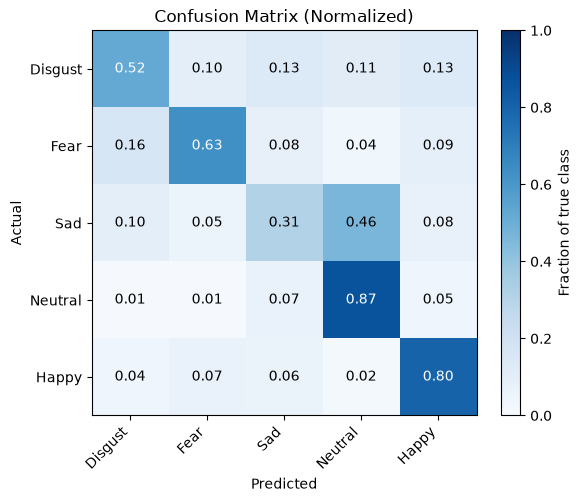

In [8]:
def plot_confusion_matrix(cm, class_names=EMOTIONS, title="Confusion Matrix (Normalized)"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, label="Fraction of true class")
    plt.tight_layout()
    plt.show()


if result is None:
    print("No results yet — set RUN_FULL_TRAINING=True in Section 6 and re-run to "
          "produce evaluation metrics.")
else:
    print(f"Test accuracy:    {result['accuracy'] * 100:.2f}%")
    print(f"Test weighted F1: {result['f1_weighted']:.4f}")

    print("\nClassification report (held-out 20% split):")
    print(classification_report(result["y_true"], result["y_pred"], target_names=EMOTIONS, digits=3))

    plot_confusion_matrix(result["confusion_matrix"])

## 8. Comparison Against the PC-SSL Baseline

Sheibani's PC-SSL baseline reports roughly **75–80% accuracy** on this random
80/20 stratified split protocol, with the same partial-freezing scheme. Because we now
fine-tune the CNN encoder end-to-end (not just a linear head on frozen features), this
comparison tests the full fine-tuning pipeline against her numbers on equal footing.

In [9]:
if result is None:
    print("Run the full training loop (Section 6) to compare against the PC-SSL "
          "baseline target of ~75-80% accuracy.")
else:
    acc = result["accuracy"] * 100
    print(f"AH-PC (partial-freeze fine-tune) accuracy: {acc:.2f}%")
    print(f"PC-SSL baseline target:                    75-80%")
    print(f"Difference vs baseline midpoint (77.5%):   {acc - 77.5:+.2f} pts")

AH-PC (partial-freeze fine-tune) accuracy: 60.00%
PC-SSL baseline target:                    75-80%
Difference vs baseline midpoint (77.5%):   -17.50 pts


## 9. Smoke Test

Before launching the full 25-epoch run, we validate the pipeline end-to-end with 2 epochs
on the real 80/20 split built in Section 3. This checks:

1. **`BandAttention`/`ChannelAttention` truly don't change.** We snapshot every weight
   tensor in those two modules before training and compare it byte-for-byte to the same
   tensors after training.
2. **Everything else does change.** The CNN encoder, bottleneck, projector, and
   classification head should all have different weights after training — if any of
   them don't, something is wired to the wrong `requires_grad` state or the wrong
   optimizer parameter group.
3. **Predictions come out in a sane shape.** A handful of predicted vs. actual labels,
   just to eyeball that nothing is index-shifted or the wrong dtype.

This is not a claim about accuracy — 2 epochs tells us nothing about whether AH-PC beats
the baseline, only that the code is correct.

In [10]:
print("=" * 70)
print("SMOKE TEST: 2 epochs on the real 80/20 split")
print("=" * 70)

SMOKE_EPOCHS = 2

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print(f"{len(train_ds):,} train pairs, {len(test_ds):,} test pairs\n")

model = AHPCClassifier(PRETRAINED_CKPT).to(DEVICE)

frozen_before = {
    "band_attn": {k: v.clone() for k, v in model.encoder.band_attn.state_dict().items()},
    "channel_attn": {k: v.clone() for k, v in model.encoder.channel_attn.state_dict().items()},
}
trainable_before = {
    "cnn": {k: v.clone() for k, v in model.encoder.encoder.state_dict().items()},
    "bottleneck": {k: v.clone() for k, v in model.encoder.bottleneck.state_dict().items()},
    "projector": {k: v.clone() for k, v in model.projector.state_dict().items()},
    "head": {k: v.clone() for k, v in model.head.state_dict().items()},
}

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=8e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))

for epoch in range(1, SMOKE_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for anchor, label in train_loader:
        anchor, label = anchor.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        logits = model(anchor)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * anchor.size(0)
    scheduler.step()
    print(f"  Epoch {epoch}/{SMOKE_EPOCHS}  train_loss={running_loss / len(train_ds):.4f}")

frozen_after = {
    "band_attn": {k: v.clone() for k, v in model.encoder.band_attn.state_dict().items()},
    "channel_attn": {k: v.clone() for k, v in model.encoder.channel_attn.state_dict().items()},
}
trainable_after = {
    "cnn": {k: v.clone() for k, v in model.encoder.encoder.state_dict().items()},
    "bottleneck": {k: v.clone() for k, v in model.encoder.bottleneck.state_dict().items()},
    "projector": {k: v.clone() for k, v in model.projector.state_dict().items()},
    "head": {k: v.clone() for k, v in model.head.state_dict().items()},
}

print()
all_frozen_unchanged = True
for name, before in frozen_before.items():
    after = frozen_after[name]
    unchanged = all(torch.equal(before[k], after[k]) for k in before)
    all_frozen_unchanged &= unchanged
    print(f"{name:14s} unchanged after training: {unchanged}")

print()
all_trainable_changed = True
for name, before in trainable_before.items():
    after = trainable_after[name]
    changed = any(not torch.equal(before[k], after[k]) for k in before)
    all_trainable_changed &= changed
    print(f"{name:14s} changed after training:   {changed}")

assert all_frozen_unchanged, "FAIL: a frozen module (band_attn/channel_attn) changed during training!"
assert all_trainable_changed, "FAIL: a module that should be trainable did not change — check requires_grad/optimizer wiring!"
print("\nAll smoke-test assertions passed.")

SMOKE TEST: 2 epochs on the real 80/20 split
18,726 train pairs, 4,682 test pairs

Restored 29 encoder tensors and 4 projector tensors from /workspaces/AH-PC/src/models/ahpc_pretrained_best.pt
  Epoch 1/2  train_loss=1.5967
  Epoch 2/2  train_loss=1.5575

band_attn      unchanged after training: True
channel_attn   unchanged after training: True

cnn            changed after training:   True
bottleneck     changed after training:   True
projector      changed after training:   True
head           changed after training:   True

All smoke-test assertions passed.


In [11]:
model.eval()
anchor_sample, label_sample = next(iter(test_loader))
with torch.no_grad():
    logits = model(anchor_sample.to(DEVICE))
    probs = F.softmax(logits, dim=-1)
    preds = probs.argmax(dim=1).cpu()

print("Sample predictions vs actual labels (2 epochs only — expect near-chance):\n")
n_show = min(10, len(preds))
for i in range(n_show):
    pred_name = EMOTIONS[preds[i].item()]
    true_name = EMOTIONS[label_sample[i].item()]
    match = "✓" if pred_name == true_name else " "
    print(f"  [{match}] Predicted: {pred_name:10s}  Actual: {true_name:10s}")

smoke_acc = accuracy_score(label_sample.numpy(), preds.numpy())
print(f"\nSmoke-test batch accuracy: {smoke_acc:.3f} (n={len(preds)}, chance level = 0.20)")

Sample predictions vs actual labels (2 epochs only — expect near-chance):

  [ ] Predicted: Happy       Actual: Disgust   
  [✓] Predicted: Sad         Actual: Sad       
  [ ] Predicted: Disgust     Actual: Neutral   
  [ ] Predicted: Fear        Actual: Sad       
  [ ] Predicted: Sad         Actual: Neutral   
  [ ] Predicted: Happy       Actual: Neutral   
  [ ] Predicted: Disgust     Actual: Neutral   
  [ ] Predicted: Neutral     Actual: Happy     
  [✓] Predicted: Sad         Actual: Sad       
  [ ] Predicted: Disgust     Actual: Happy     

Smoke-test batch accuracy: 0.281 (n=32, chance level = 0.20)
